In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [7]:
import os
print("Current Working Directory:", os.getcwd())


Current Working Directory: C:\Users\WIN\Advanced Heart Attack Risk Prediction


In [9]:
# ================================================================
# ✅ Step 2: Load Dataset
# ================================================================
df = pd.read_csv("C:/Users/WIN/Advanced Heart Attack Risk Prediction/data/heart.csv")
 # Make sure heart.csv is in your working directory

print("✅ Dataset Loaded Successfully!")
print("Shape of Dataset:", df.shape)
df.head()

✅ Dataset Loaded Successfully!
Shape of Dataset: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [22]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [10]:
# ================================================================
# ✅ Step 3: Data Understanding
# ================================================================
print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal     

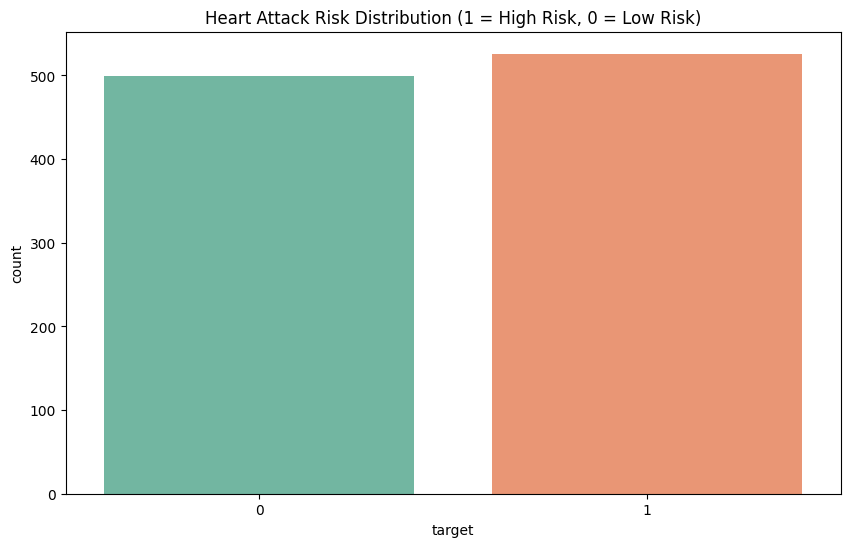

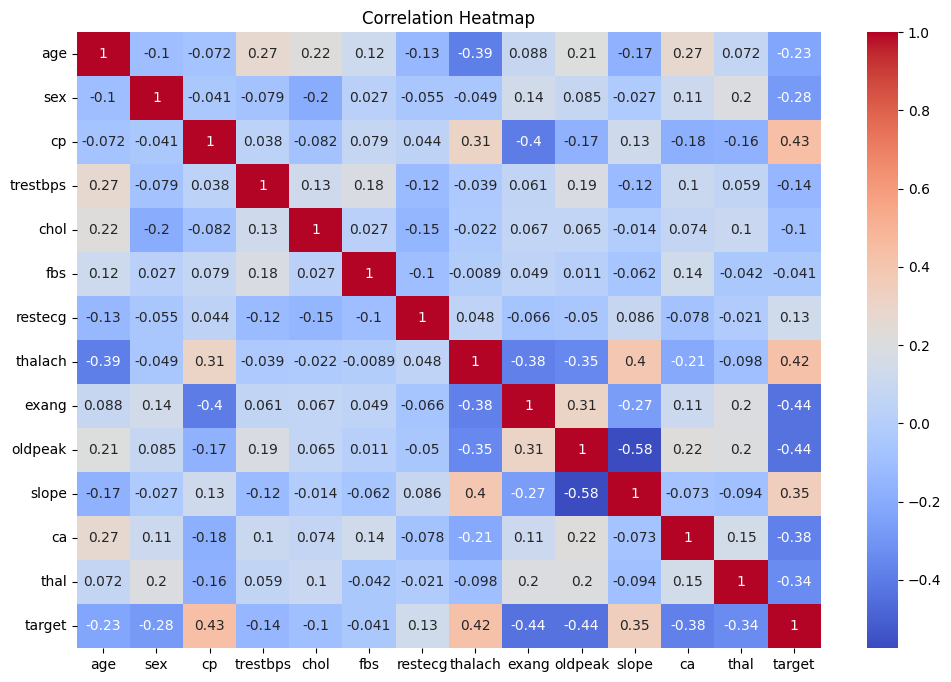

In [12]:
# ================================================================
# ✅ Step 4: Exploratory Data Analysis (EDA)
# ================================================================
plt.figure(figsize=(10,6))
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Heart Attack Risk Distribution (1 = High Risk, 0 = Low Risk)")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# ================================================================
# ✅ Step 5: Data Preprocessing
# ================================================================
X = df.drop(columns=['target'])
y = df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Preprocessing Completed!")

✅ Data Preprocessing Completed!


In [15]:
# ================================================================
# ✅ Step 6: Define Base Models and Meta Model (Stacking)
# ================================================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, random_state=42)
svc = SVC(probability=True, kernel='rbf', C=1, random_state=42)

meta_model = LogisticRegression(random_state=42)

stacked_model = StackingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('svc', svc)],
    final_estimator=meta_model,
    cv=5
)

In [16]:
# ================================================================
# ✅ Step 7: Train the Stacked Hybrid Model
# ================================================================
stacked_model.fit(X_train_scaled, y_train)
print("✅ Stacked Hybrid Model Trained Successfully!")



✅ Stacked Hybrid Model Trained Successfully!


✅ Model Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



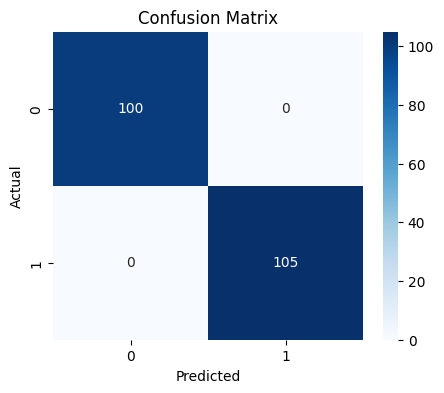

In [17]:
# ================================================================
# ✅ Step 8: Model Evaluation
# ================================================================
y_pred = stacked_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {acc:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# ================================================================
# ✅ Step 9: Compare Base Model Performances
# ================================================================
models = {
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "SVM": svc
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    print(f"{name} Accuracy: {accuracy_score(y_test, pred):.4f}")


Random Forest Accuracy: 1.0000
Gradient Boosting Accuracy: 0.9659
SVM Accuracy: 0.9268


In [23]:
# ================================================================
# ✅ Step 10: Predict for a New User Input (Fully Fixed Version)
# ================================================================

# Create a sample patient record
sample_data = pd.DataFrame({
    'age': [52],
    'sex': [1],
    'cp': [0],
    'trestbps': [125],   # ✅ Corrected spelling
    'chol': [212],
    'fbs': [0],
    'restecg': [1],
    'thalach': [168],
    'exang': [0],
    'oldpeak': [1.0],
    'slope': [2],
    'ca': [0],
    'thal': [2]
})

# Scale and Predict
scaled_sample = scaler.transform(sample_data)
prediction = stacked_model.predict(scaled_sample)
prob = stacked_model.predict_proba(scaled_sample)[0][1]

# Display Result
result = "💔 High Risk of Heart Attack" if prediction[0] == 1 else "💚 Low Risk of Heart Attack"
print("\nPredicted Result for the Sample:")
print(result)
print(f"Prediction Probability (High Risk): {prob*100:.2f}%")



Predicted Result for the Sample:
💔 High Risk of Heart Attack
Prediction Probability (High Risk): 98.03%
